/usr/lib/python3/dist-packages/osgeo/gdal.py:606: FutureWarning: Neither gdal.UseExceptions() nor gdal.DontUseExceptions() has been explicitly called. In GDAL 4.0, exceptions will be enabled by default.
  warnings.warn(


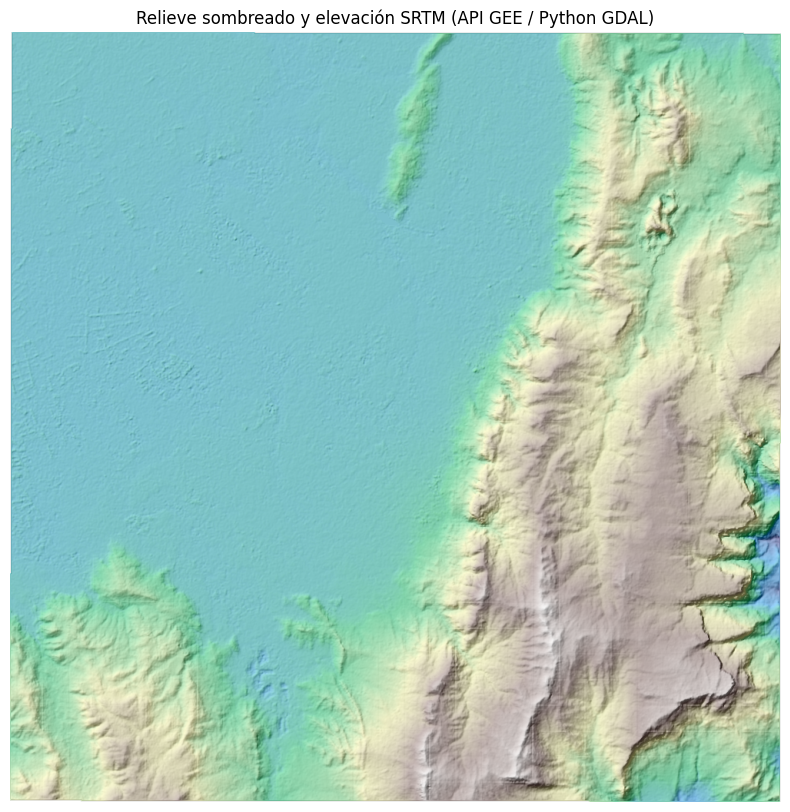

In [3]:
#| label: python_gdal_hillshade
#| eval: false
#| echo: true

from osgeo import gdal
import rasterio
from rasterio.plot import show
import matplotlib.pyplot as plt

# Uso del directorio data/
ruta_mde_4326 = "data/mde_bogota_srtm_elevation.tif"
ruta_mde_9377 = "data/mde_bogota_9377_py.tif"

# 1. Reproyección Origen Nacional
ds_warp = gdal.Warp(ruta_mde_9377, ruta_mde_4326, dstSRS="EPSG:9377")
ds_warp = None # Cierre de puntero C++

# 2. Generación de Derivados Topográficos

ruta_pendiente = "data/mde_bogota_slope_py.tif"
ruta_orientacion = "data/mde_bogota_aspect_py.tif"
ruta_sombreado = "data/mde_bogota_hillshade_py.tif"

ds_slope = gdal.DEMProcessing(ruta_pendiente, ruta_mde_9377, "slope")
ds_slope = None
ds_aspect = gdal.DEMProcessing(ruta_orientacion, ruta_mde_9377, "aspect")
ds_aspect = None
ds_hill = gdal.DEMProcessing(ruta_sombreado, ruta_mde_9377, "hillshade", azimuth=315, altitude=45)
ds_hill = None

# 3. Renderizado Python

with rasterio.open(ruta_mde_9377) as mde_src, rasterio.open(ruta_sombreado) as hill_src:
    fig, ax = plt.subplots(figsize=(10, 10))
    show(hill_src, ax=ax, cmap='Greys_r')
    show(mde_src, ax=ax, cmap='terrain', alpha=0.4)
    ax.set_title("Relieve sombreado y elevación SRTM (API GEE / Python GDAL)")
    ax.set_axis_off() 
    plt.show()